# 1. Quais são as tendências de vendas ao longo do tempo?
    - Como as vendas variam ao longo dos meses e anos?
    - Existem sazonalidades que podem ser exploradas para campanhas de marketing?
# 2. Qual é o perfil dos clientes?
    - Qual é a distribuição de idades dos cleintes?
    - Como as vendas variam entre diferentes grupos etários e gêneros?
# 3. Quais são os produtos mais vendidos?
    - Quais categorias e subcategorias de produtos são mais populares?
    - Como a demanda por diferentes produtos varias ao longo do tempo?
# 4. Análise Geográfica
    - Quais são os principais mercados (países e estados) em termos de vendas?
    - Existe potêncial para expansão em regiões repecíficas?
# 5. Análise de Margem de Lucro
    - Quais produtos ou categorias têm a maior margem de lucro?
    - Como otimizar o mix de produtos para maximizar a lucratividade?
# 6. Comportamento de Compra dos Clientes
    - Qual é  a frequência de compra dos clientes?
    - Existem clientes recorrentes e qual é o seu impacto nas vendas totais?
# 7. Eficiência de Custos
    - Qual é a relação entre o custo unitário e o preço unitário dos produtos?
    - Existem oportunidades para reduzir os custos e aumentar a margem de lucro?

In [53]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [54]:
df = pd.read_csv("Sales.csv")
df.info() #DataFrame não possui valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost              113036 non-null  int

In [55]:
#Colocando todos as colunas para letras minusculas
df.columns = [x.lower() for x in df.columns]
#Colocando a coluna date para datetime
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              113036 non-null  datetime64[ns]
 1   day               113036 non-null  int64         
 2   month             113036 non-null  object        
 3   year              113036 non-null  int64         
 4   customer_age      113036 non-null  int64         
 5   age_group         113036 non-null  object        
 6   customer_gender   113036 non-null  object        
 7   country           113036 non-null  object        
 8   state             113036 non-null  object        
 9   product_category  113036 non-null  object        
 10  sub_category      113036 non-null  object        
 11  product           113036 non-null  object        
 12  order_quantity    113036 non-null  int64         
 13  unit_cost         113036 non-null  int64         
 14  unit

In [57]:
# 1) Quantidade total de vendas cada dia.
qtdd_total = df.groupby("date")[["order_quantity"]].sum() #Poderia tirar essa lista de listas para utilizar sem o squeeze()

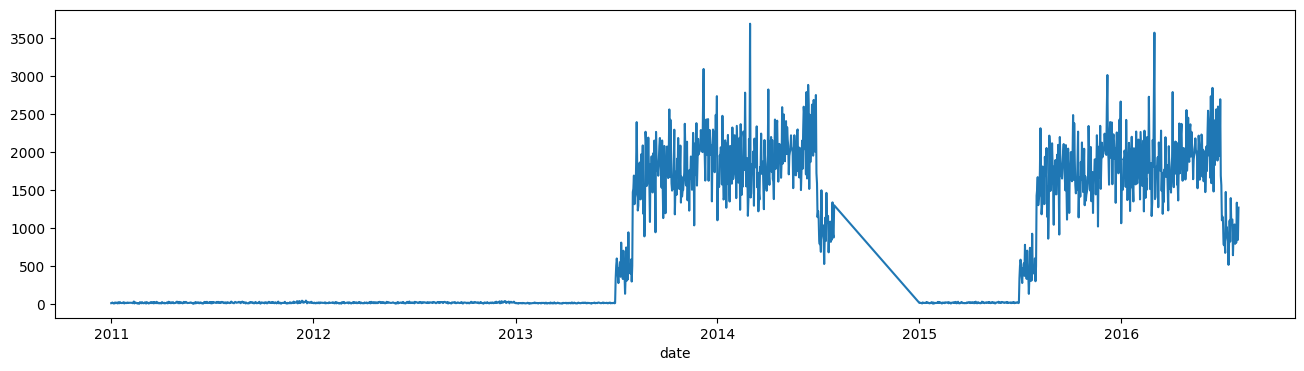

In [58]:
# Visualizar em termos de um gráfico para melhorar a visualizaçao em uma serie temporal
plt.figure(figsize=(16,4)) # Aumentar o gráfico
sns.lineplot(x = qtdd_total.index, y = qtdd_total.values.squeeze()) #squeeze() - Deixa o array em forma unidimensional
plt.show()

Em meados de 2013 as vendas começaram a explodir, temos uma tendencia clara de alta até meados de 2014, em que as vendas caíram novamente até meados de 2015 que as vendas voltaram!
Como a escala grande de 5 anos tivemos muito mais vendas em alguns anos que outros, isso faz com que a escala do eixo y seja afetada e quase nao conseguimos enxergar a dinamica de vendas nos anos iniciais.
* Isso é um bom motivo para visualizar ano a ano

In [59]:
qtdd_total

,order_quantity
date,
2011-01-01,8
2011-01-02,9
2011-01-03,17
2011-01-04,10
2011-01-05,5
...,...
2016-07-27,807
2016-07-28,1332
2016-07-29,895


Para evitar oscilações muito grande: Aplica uma determinada janela de tempo e agrega as informações dentro dessa janela com a funçao de agregaçao mean()
* Deixar ela mais "suave"
* Quanto maior a quantidade de dias, maior a janela, mais suave

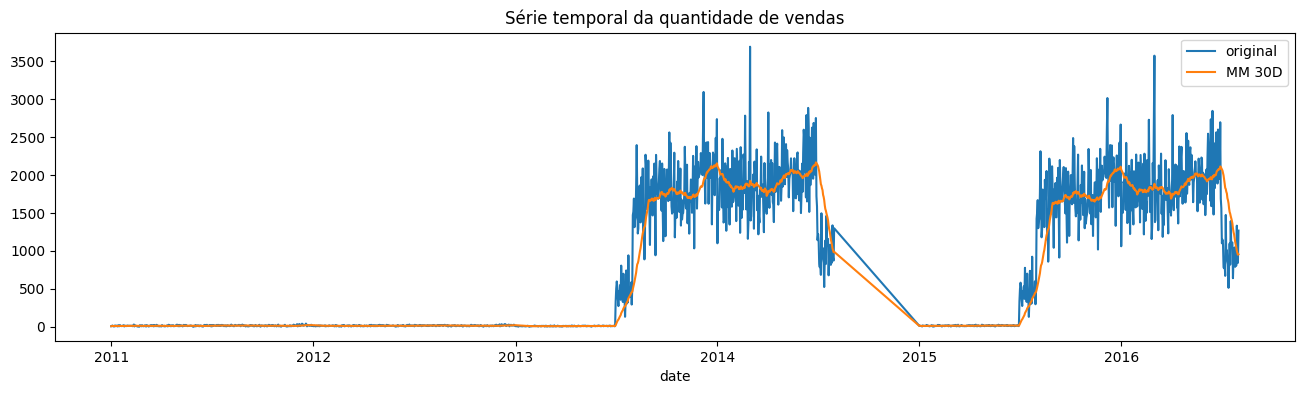

In [60]:
# Rolling - O indice precisa ser datetime para ele funcionar de maneira simples.
qtdd_total_30d = qtdd_total.rolling(window = "30D").mean()
qtdd_total_3d = qtdd_total.rolling(window = "3D").mean() #Criar uma janela de 3 dias e ir deslizando ela pelos dados e calculando a media desses valores e colocando dentro de cada celula 

plt.figure(figsize=(16,4))
plt.title("Série temporal da quantidade de vendas")

sns.lineplot(x = qtdd_total.index, y = qtdd_total.values.squeeze(), label = "original")
#sns.lineplot(x = qtdd_total_3d.index, y = qtdd_total_3d.values.squeeze(), label = "MM 3D")
sns.lineplot(x = qtdd_total_30d.index, y = qtdd_total_30d.values.squeeze(), label = "MM 30D")

plt.show()

* Com a janela de 3 dias não fica uma visualizaçao muito boa
* Com a janela de 30 dias é possível observar de maneira muito mais clara como ficou essa oscilação esse padrão de vendas que subiu mes a mes, enxergar melhor as tendencias integrando todo o ruido.
* Fica evidente que o periodo de julho de 2013 até julho de 2014 é muito parecido com julho de 2015 até julho de 2016.
* Podem ser dados "criados" apenas copiados

Mas ainda não é possivel visualizar a evolução de vendas nos primeiros 2 anos e meio, por isso irei visualizar essa série ano a ano.

In [61]:
for ano in df["year"].sort_values().unique():
    print(ano)

2011
2012
2013
2014
2015
2016


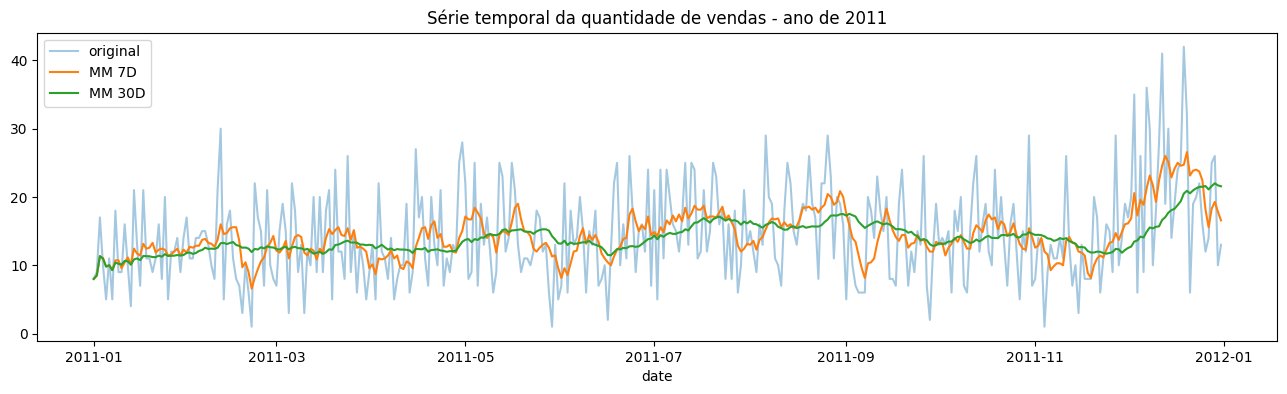

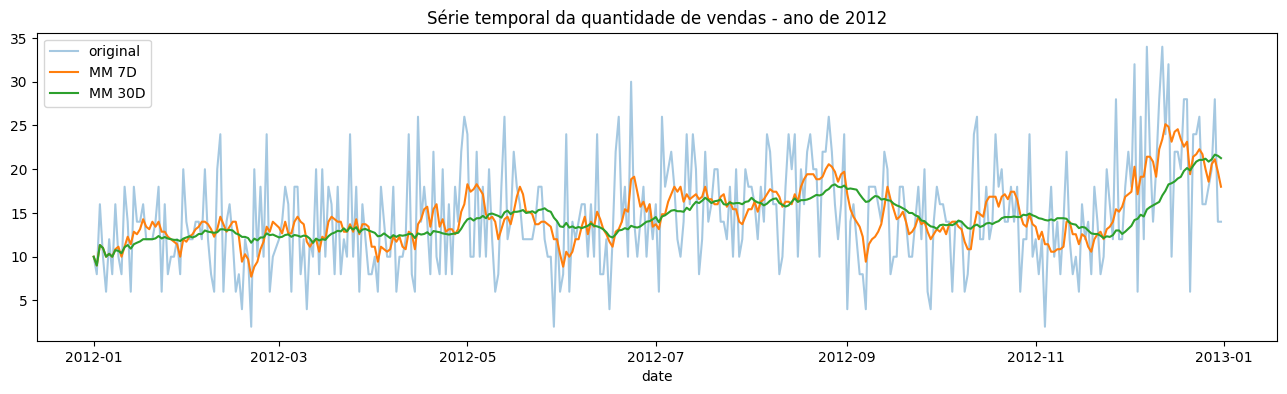

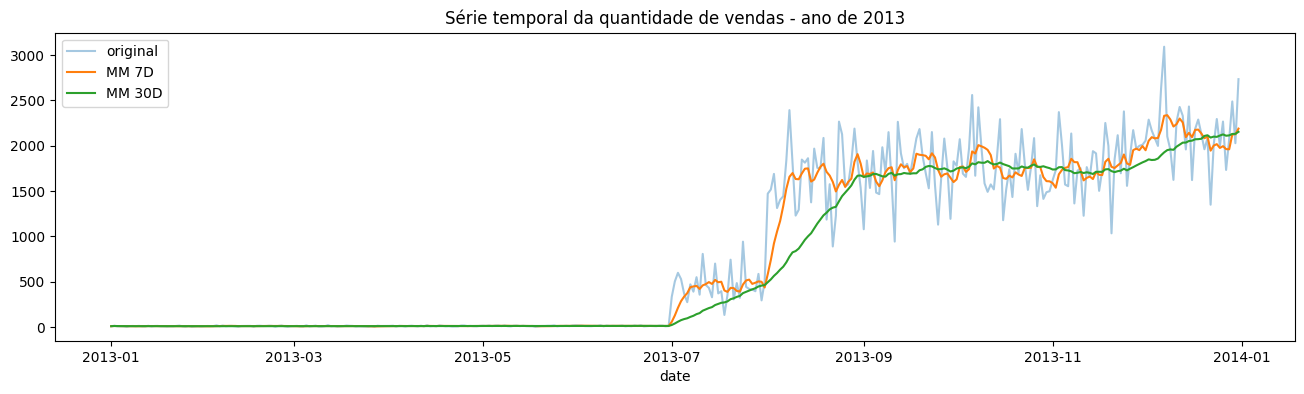

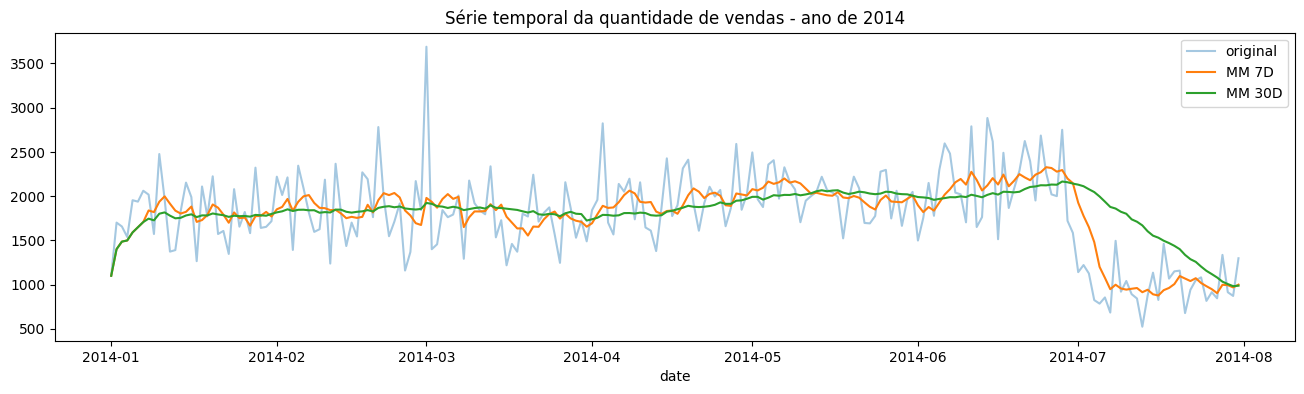

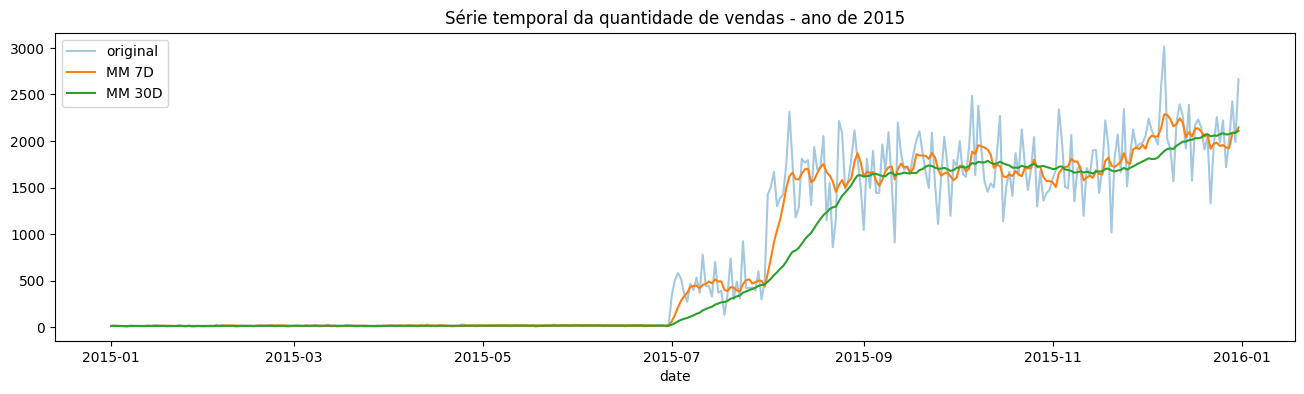

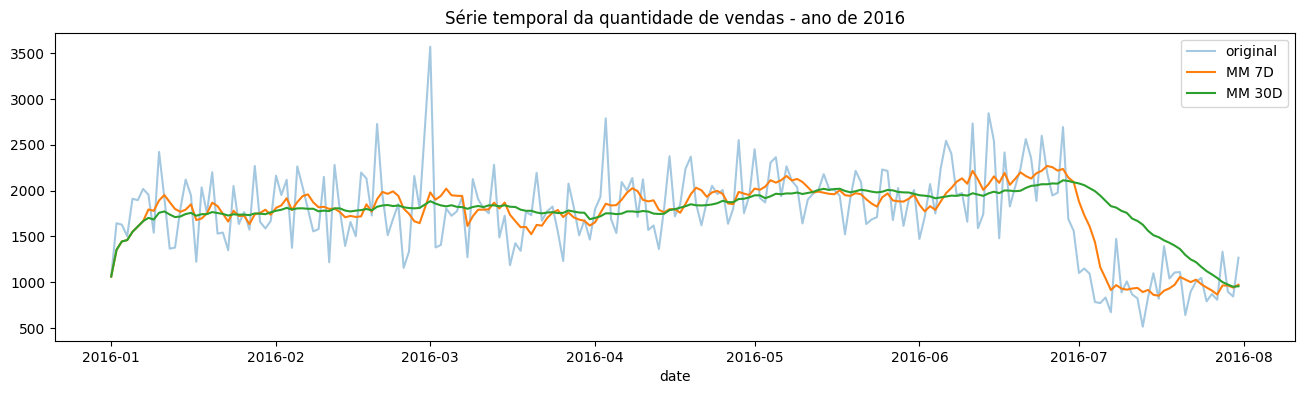

In [62]:
#Plotar somente os periodos necessários
for ano in df["year"].sort_values().unique():
    df_ano = df.query(f"year == {ano}")
    qtdd_total = df_ano.groupby("date")[["order_quantity"]].sum()

    qtdd_total_30d = qtdd_total.rolling(window = "30D").mean()
    qtdd_total_7d = qtdd_total.rolling(window = "7D").mean() #Criar uma janela de 3 dias e ir deslizando ela pelos dados e calculando a media desses valores e colocando dentro de cada celula 

    plt.figure(figsize=(16,4))
    plt.title(f"Série temporal da quantidade de vendas - ano de {ano}")

    sns.lineplot(x = qtdd_total.index, y = qtdd_total.values.squeeze(), label = "original", alpha =0.4) #Deixar mais transparente)
    sns.lineplot(x = qtdd_total_7d.index, y = qtdd_total_7d.values.squeeze(), label = "MM 7D")
    sns.lineplot(x = qtdd_total_30d.index, y = qtdd_total_30d.values.squeeze(), label = "MM 30D")

* Olhando para os gráficos 2011 e 2012 são muito parecidos temos um perfil muito claro dessa evolução, não são exatamente igual, percebe-se que em janeiro de 2012 teve um pico de vendas um pouco maior, dado que a média movel de uma semana tá um pouco mais distânciada da media móvel mensal, embora as quantidades exatamente não seja as mesmas tivemos um perfil muito parecido, com a media movel semanal um pouco a cima da mensal. O padrão de como as vendas funcionaram nesses dois anos, é muito parecido ficou estagnado e ao final deu uma leve subida.
* Já em 2013 acontece algo interessante, podemos observar que a partir de julho temos uma subida de vendas considerável, as vendas chegam perto de 3000 nesse período, aconteceu alguam estratégia, alguma mudança, o ideal é conversar com a área de negócio para entender o que aconteceu nesse período. Continua essa tendência de crescimento até setembro, depois ele vai estagnando, mas tem uma leve tendência de alta.
* Quando vamos para 2014 continua alta a taxa de vendas, não em 3000, mas proximo de 2000, teve uma pequena baixa, mas se manteve estável até julho, começou a cair novamente e vai vertiginosamente, os gráficos estavam até 2014 do inicio até o final, mas em 2014 temos dados somente até agosto, depois desse periodo só tem dados até inicio de 2015, temos um buraco na série, ou seja, não temos dados nesse período. Ex: a loja ficou fora do ar, teve algum erro na contabilização, entre outros.
* Em 2015 voltou as vendas lá embaixo, uma hipotese clara é que a loja ficou fora do ar nesse período, em 2015 quando volta já não estava tão quente a loja, levou novamente 6 meses para a tendência de alta parecida com 2013.
* E em 2016 uma tendência bem parecida com 2014 em julho de 2016 ele volta a cair até agosto.

In [63]:
#agrupar os dados pelo mes
df.groupby("month")[["order_quantity"]].sum()

,order_quantity
month,
April,118467
August,103119
December,133312
February,104717
January,110367
July,89787
June,128591
March,111085
May,125715


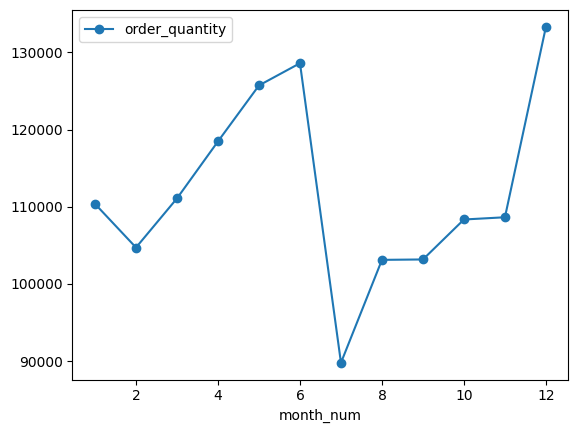

In [64]:
#Colocando os meses em ordem crescente
df["month_num"] = df["date"].apply(lambda x: x.month)
#agrupar os dados pelo mes
df.groupby("month_num")[["order_quantity"]].sum().plot(marker="o")
plt.show()

Quantidade total de vendas - ano de 2011


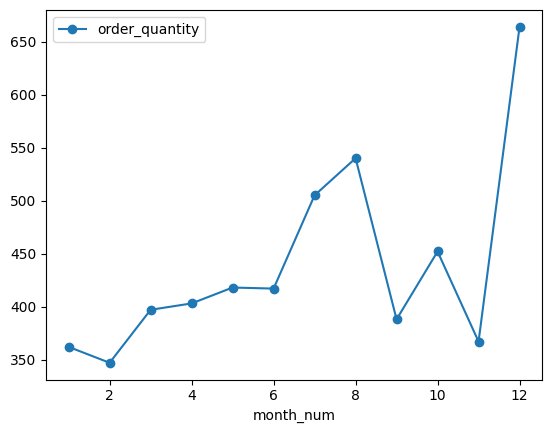

Quantidade total de vendas - ano de 2012


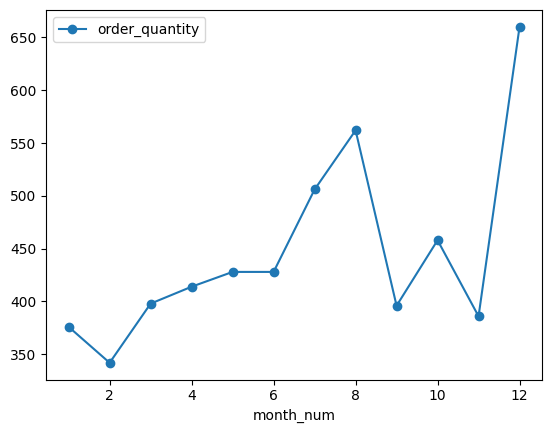

Quantidade total de vendas - ano de 2013


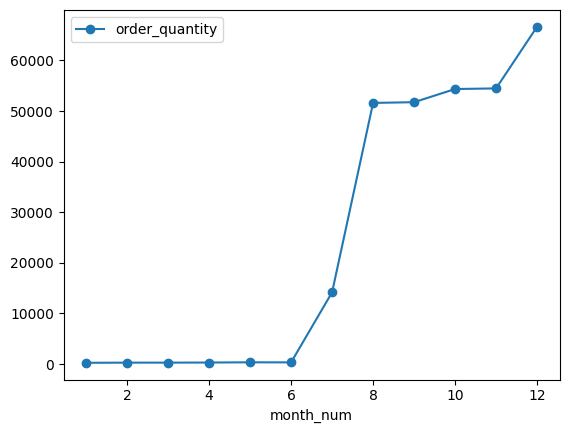

Quantidade total de vendas - ano de 2014


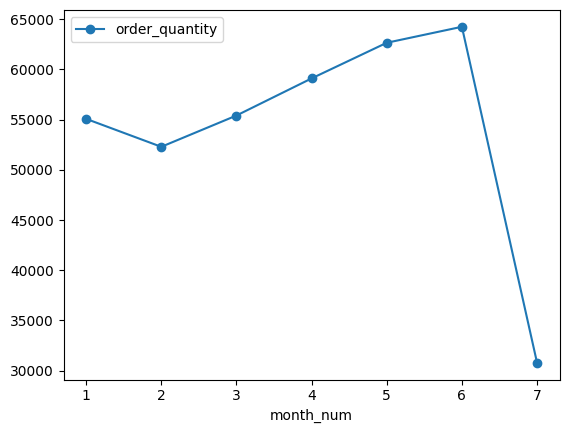

Quantidade total de vendas - ano de 2015


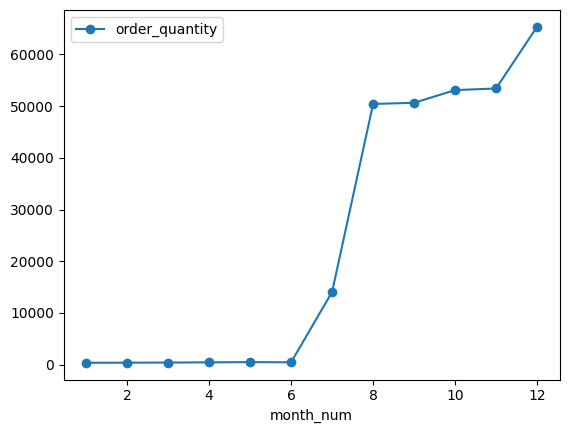

Quantidade total de vendas - ano de 2016


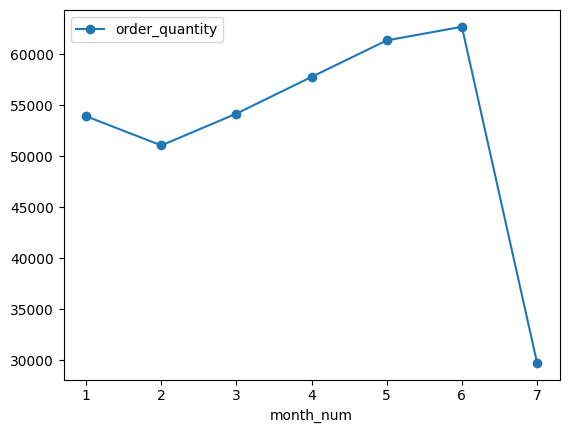

In [65]:
for ano in df["year"].sort_values().unique():

    df_ano = df.query(f"year == {ano}")

    print(f"Quantidade total de vendas - ano de {ano}")
    df_ano.groupby("month_num")[["order_quantity"]].sum().plot(marker="o")
    plt.show()

## 2 - Qual o perffil dos clientes

In [66]:
df["customer_gender"].describe()

count     113036
unique         2
top            M
freq       58312
Name: customer_gender, dtype: object

In [67]:
df["customer_gender"].value_counts(normalize= True)

customer_gender
M    0.515871
F    0.484129
Name: proportion, dtype: float64

In [68]:
df["age_group"].describe()

count             113036
unique                 4
top       Adults (35-64)
freq               55824
Name: age_group, dtype: object

In [69]:
df["age_group"].value_counts()

age_group
Adults (35-64)          55824
Young Adults (25-34)    38654
Youth (<25)             17828
Seniors (64+)             730
Name: count, dtype: int64

In [70]:
df["customer_age"].describe() #Em média os clientes tem quase 36 anos

count    113036.000000
mean         35.919212
std          11.021936
min          17.000000
25%          28.000000
50%          35.000000
75%          43.000000
max          87.000000
Name: customer_age, dtype: float64

* Em média os clientes tem quase 36 anos
* O mais novo tem 17
* O mais velho tem 87
* É uma distribuição com a media ligeiramente maior que a mediana logo a cauda será mais pronunciada para a direita

<Axes: xlabel='customer_age', ylabel='Count'>

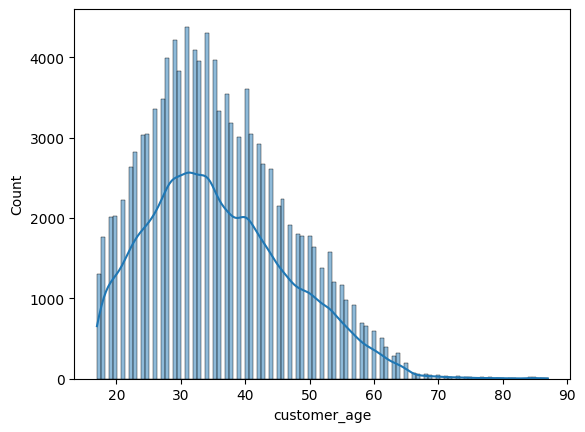

In [71]:
sns.histplot(data = df, x="customer_age", kde = True)

Essa distribuição separada por generos muda?
Essencialmente não altera tanto as distribuições estão muuito coladas uma na outra o que acontece é que nas idades iniciais temos mais homens que mulheres, mas posteriormente eles se equilibram.

<Axes: xlabel='customer_age', ylabel='Count'>

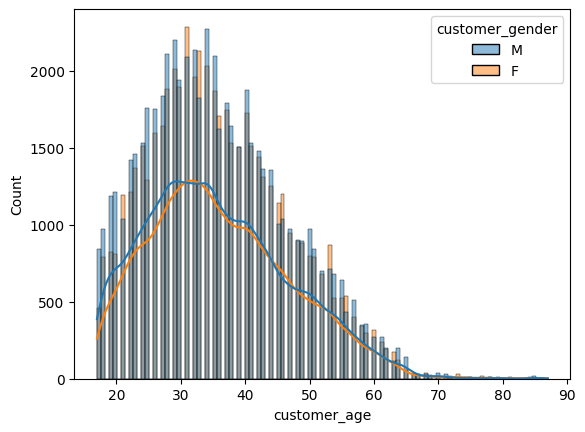

In [72]:
sns.histplot(data = df, x="customer_age", kde = True, hue = "customer_gender")

Fazendo uma análise ano a ano

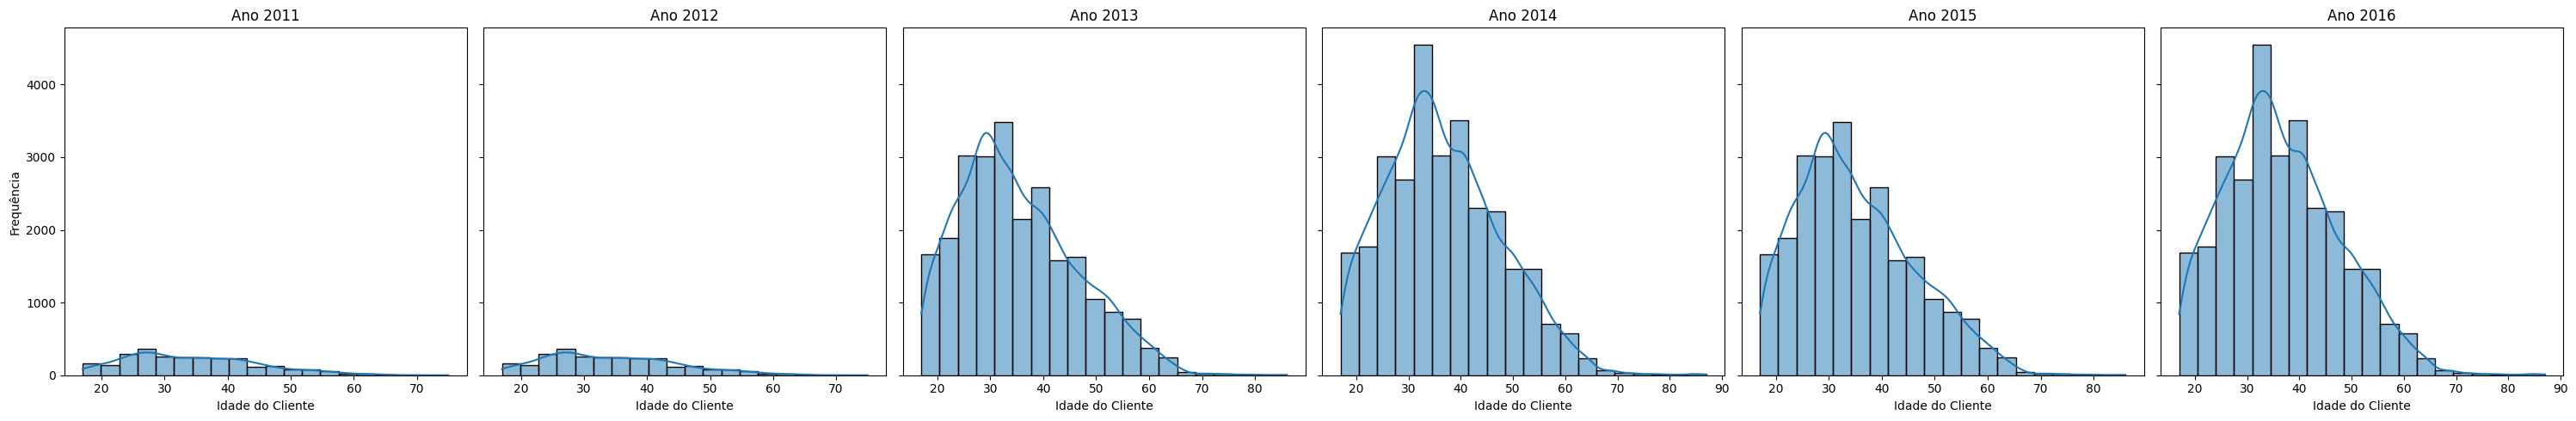

In [73]:
years = sorted(df["year"].unique()) # Lita de anos ordenada
num_year = len(years) # Número total de anos
fig, axes = plt.subplots(1, num_year, figsize = (5 *num_year,5), sharey=True)

# Plotando um histograma para cada ano
for i, year in enumerate(years):
    sns.histplot(df[df["year"] == year]["customer_age"], bins=20, ax=axes[i], kde=True)
    axes[i].set_title(f"Ano {year}")
    axes[i].set_xlabel("Idade do Cliente")
    axes[i].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

Os histogramas acima representam a distribuição da idade dos clientes ao longo dos anos de **2011 a 2015**. A seguir, destacamos algumas observações importantes:

## **1. Tendência Geral**
- A partir de **2013**, observa-se um aumento significativo no número de clientes, com um formato mais bem definido na distribuição etária.
- Os anos de **2011 e 2012** apresentam uma quantidade menor de clientes, com uma distribuição mais dispersa.

## **2. Faixa Etária Predominante**
- Entre **2013 e 2015**, a maior parte dos clientes se concentra na faixa de **30 a 50 anos**, com um pico por volta dos **35-45 anos**.
- Os dados sugerem que esse grupo representa o público-alvo mais frequente na compra de bicicletas.

## **3. Evolução da Distribuição**
- Em **2013**, a distribuição começa a assumir um padrão claro, com um aumento no número de clientes nas idades centrais.
- Nos anos seguintes (**2014 e 2015**), a distribuição mantém um comportamento semelhante, reforçando a ideia de que a faixa etária entre **30 e 50 anos** continua sendo a mais ativa.

## **4. Considerações Finais**
- O aumento no volume de clientes a partir de **2013** pode indicar um crescimento do mercado ou uma melhora na coleta de dados.
- Os anos iniciais (**2011 e 2012**) podem ter uma baixa representatividade devido a menor quantidade de registros ou início da operação.
- O formato das distribuições sugere que o público-alvo é composto majoritariamente por **adultos de meia-idade**, o que pode ser útil para estratégias de marketing e direcionamento de vendas.

In [74]:
for ano in df["year"].sort_values().unique():

    df_ano = df.query(f"year == {ano}")

    print(f"Distribuição de gênero - ano de {ano}")
    display(df_ano["customer_gender"].value_counts(normalize=True))
    print(f"\n{'='*80}\n")

Distribuição de gênero - ano de 2011


customer_gender
F    0.513261
M    0.486739
Name: proportion, dtype: float64



Distribuição de gênero - ano de 2012


customer_gender
F    0.513261
M    0.486739
Name: proportion, dtype: float64



Distribuição de gênero - ano de 2013


...

customer_gender
M    0.528301
F    0.471699
Name: proportion, dtype: float64



Distribuição de gênero - ano de 2015


customer_gender
M    0.504112
F    0.495888
Name: proportion, dtype: float64



Distribuição de gênero - ano de 2016


customer_gender
M    0.528301
F    0.471699
Name: proportion, dtype: float64

* O balanço fica bem equilabrado todos os anos, quase 50/50.
* 2011 e 2012 - mais mulhere que homens
* 2012 para frente mais homens
* podendo fazer campanhas especificas para trazer mais clientes mulheres

In [75]:
for ano in df["year"].sort_values().unique():

    df_ano = df.query(f"year == {ano}")

    print(f"Distribuição de faixa etária - ano de {ano}")
    display(df_ano["age_group"].value_counts(normalize=True))
    print(f"\n{'='*80}\n")

Distribuição de faixa etária - ano de 2011


age_group
Adults (35-64)          0.450878
Young Adults (25-34)    0.363840
Youth (<25)             0.182667
Seniors (64+)           0.002615
Name: proportion, dtype: float64



Distribuição de faixa etária - ano de 2012


age_group
Adults (35-64)          0.450878
Young Adults (25-34)    0.363840
Youth (<25)             0.182667
Seniors (64+)           0.002615
Name: proportion, dtype: float64



Distribuição de faixa etária - ano de 2013


...

age_group
Adults (35-64)          0.526192
Young Adults (25-34)    0.325464
Youth (<25)             0.140622
Seniors (64+)           0.007722
Name: proportion, dtype: float64



Distribuição de faixa etária - ano de 2015


age_group
Adults (35-64)          0.459682
Young Adults (25-34)    0.359408
Youth (<25)             0.175551
Seniors (64+)           0.005359
Name: proportion, dtype: float64



Distribuição de faixa etária - ano de 2016


age_group
Adults (35-64)          0.526192
Young Adults (25-34)    0.325464
Youth (<25)             0.140622
Seniors (64+)           0.007722
Name: proportion, dtype: float64

* A distribuição não ocorreu inversãoes ou seja, sempre mais adultos, depoiis adulto-jovens, jovens e por ultimo senhores.

Como ver a contribuição de cada faixa etária para quantidade de vendas

In [76]:
df.groupby("age_group")[["order_quantity"]].sum()

,order_quantity
age_group,
Adults (35-64),672417
Seniors (64+),9877
Young Adults (25-34),446875
Youth (<25),216147


In [77]:
faixa_etaria_ano = df.groupby("age_group year".split())[["order_quantity"]].sum().reset_index()
faixa_etaria_ano

,age_group,year,order_quantity
0,Adults (35-64),2011,2337
1,Adults (35-64),2012,2414
2,Adults (35-64),2013,136850
3,Adults (35-64),2014,200609
4,Adults (35-64),2015,134073
5,Adults (35-64),2016,196134
6,Seniors (64+),2011,12
7,Seniors (64+),2012,14
8,Seniors (64+),2013,1998
9,Seniors (64+),2014,3004


<Axes: xlabel='year', ylabel='order_quantity'>

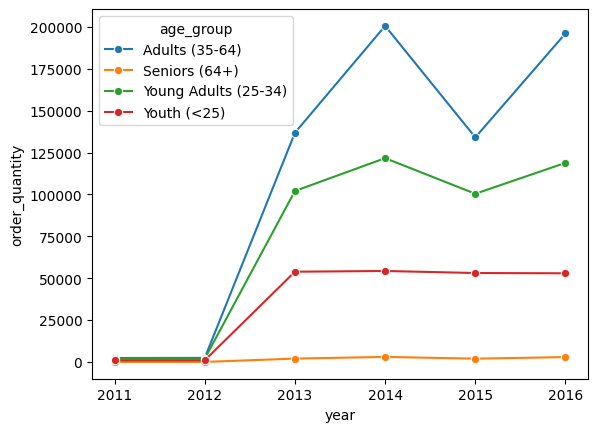

In [78]:
sns.lineplot(data = faixa_etaria_ano, x="year",y="order_quantity", hue="age_group", marker = "o")

<Axes: xlabel='year', ylabel='order_quantity'>

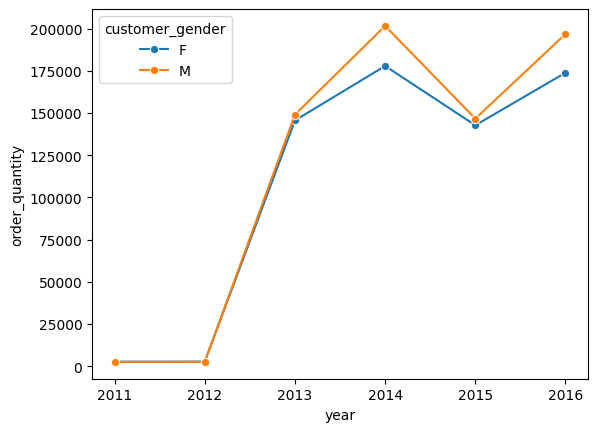

In [79]:
genero_ano = df.groupby("customer_gender year".split())[["order_quantity"]].sum().reset_index()
sns.lineplot(data = genero_ano, x="year",y="order_quantity", hue="customer_gender", marker = "o")

## 3) Analise geográfica
 * Trabalhar com as colunas country e state

In [80]:
df["country"].unique()

array(['Canada', 'Australia', 'United States', 'Germany', 'France',
       'United Kingdom'], dtype=object)

In [81]:
df["state"].nunique() # 53 estados

53

In [82]:
df["state"].unique()

array(['British Columbia', 'New South Wales', 'Victoria', 'Oregon',
       'California', 'Saarland', 'Seine Saint Denis', 'Moselle',
       'Queensland', 'England', 'Nord', 'Washington', 'Hessen',
       'Nordrhein-Westfalen', 'Hamburg', 'Loir et Cher', 'Kentucky',
       'Seine (Paris)', 'South Australia', 'Loiret', 'Alberta', 'Bayern',
       'Hauts de Seine', 'Yveline', 'Essonne', "Val d'Oise", 'Tasmania',
       'Seine et Marne', 'Val de Marne', 'Pas de Calais',
       'Charente-Maritime', 'Garonne (Haute)', 'Brandenburg', 'Texas',
       'New York', 'Florida', 'Somme', 'Illinois', 'South Carolina',
       'North Carolina', 'Georgia', 'Virginia', 'Ohio', 'Ontario',
       'Wyoming', 'Missouri', 'Montana', 'Utah', 'Minnesota',
       'Mississippi', 'Massachusetts', 'Arizona', 'Alabama'], dtype=object)

### proporção de Paises - por aparição na base

In [83]:
df["country"].value_counts(normalize=True)

country
United States     0.346845
Australia         0.211756
Canada            0.125429
United Kingdom    0.120493
Germany           0.098181
France            0.097296
Name: proportion, dtype: float64

<Axes: xlabel='country', ylabel='count'>

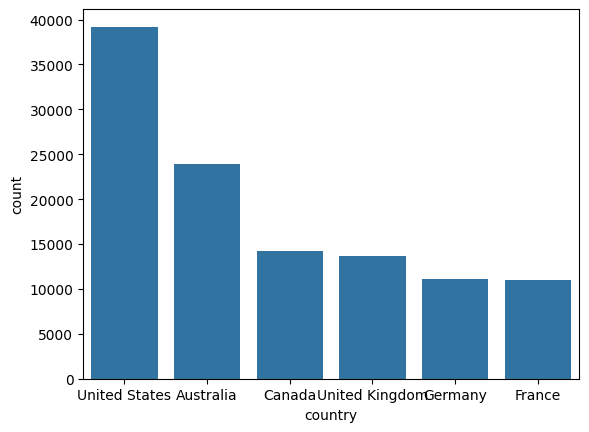

In [84]:
sns.countplot(data = df, x="country",order=df["country"].value_counts(normalize=True).index)

### proporção de Paises - por quantidade vendida

In [85]:
pais_qtdd = df.groupby("country")[["order_quantity"]].sum().reset_index()
pais_qtdd

,country,order_quantity
0,Australia,263585
1,Canada,192259
2,France,128995
3,Germany,125720
4,United Kingdom,157218
5,United States,477539


<Axes: xlabel='country', ylabel='order_quantity'>

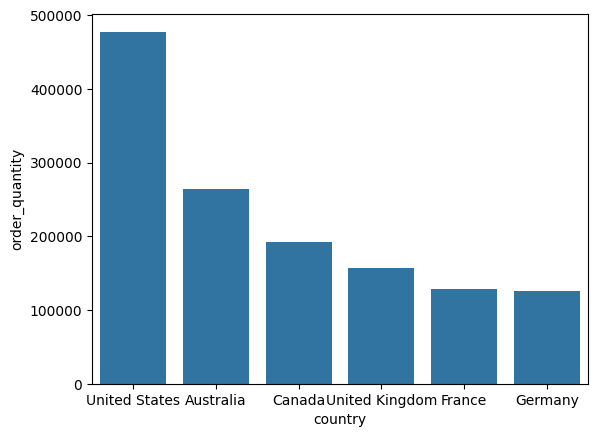

In [86]:
sns.barplot(data=pais_qtdd.sort_values("order_quantity", ascending=False), x="country",y="order_quantity")

Comparando os dois gráficos, o eixo y altera uma pouco a escala, mas matemos algo muito parecido.

In [87]:
for ano in df["year"].sort_values().unique():

    df_ano = df.query(f"year == {ano}")

    print(f"quantidade de aparição por país - ano de {ano}")
    display(df_ano["country"].value_counts(normalize=True))
    print(f"\n{'='*80}\n")

quantidade de aparição por país - ano de 2011


country
United States     0.321629
Australia         0.320882
United Kingdom    0.098991
Germany           0.087038
France            0.087038
Canada            0.084423
Name: proportion, dtype: float64



quantidade de aparição por país - ano de 2012


country
United States     0.321629
Australia         0.320882
United Kingdom    0.098991
Germany           0.087038
France            0.087038
Canada            0.084423
Name: proportion, dtype: float64



quantidade de aparição por país - ano de 2013


...

country
United States     0.348017
Australia         0.196408
Canada            0.128478
United Kingdom    0.121743
Germany           0.104157
France            0.101197
Name: proportion, dtype: float64



quantidade de aparição por país - ano de 2015


country
United States     0.348198
Australia         0.218263
Canada            0.126253
United Kingdom    0.121344
France            0.093728
Germany           0.092215
Name: proportion, dtype: float64



quantidade de aparição por país - ano de 2016


country
United States     0.348017
Australia         0.196408
Canada            0.128478
United Kingdom    0.121743
Germany           0.104157
France            0.101197
Name: proportion, dtype: float64

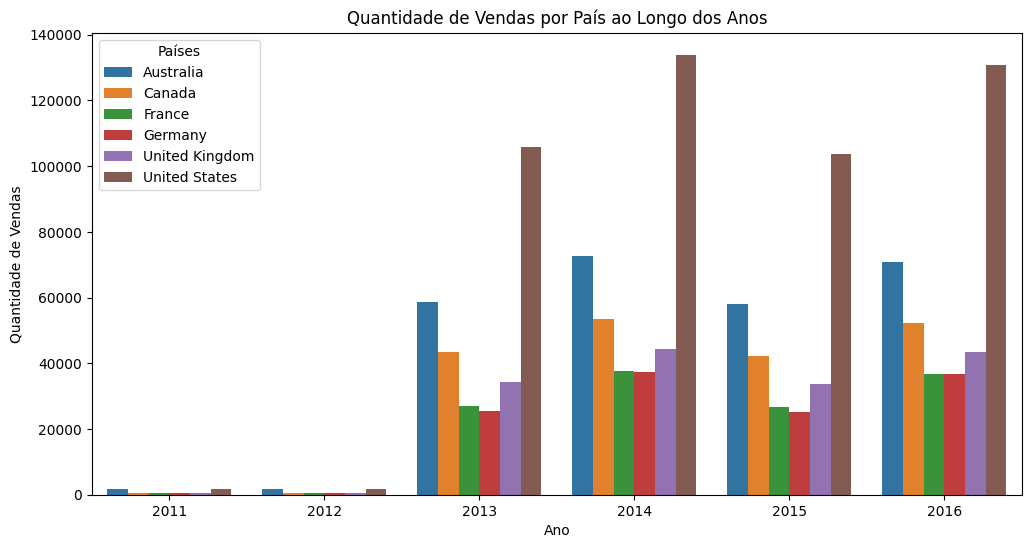

In [88]:
pais_qtdd_ano = df.groupby("country year".split())[["order_quantity"]].sum()
# Criar gráfico de barras agrupadas
plt.figure(figsize=(12, 6))
sns.barplot(data=pais_qtdd_ano, x="year", y="order_quantity", hue="country", palette="tab10")

# Adicionar rótulos e título
plt.xlabel("Ano")
plt.ylabel("Quantidade de Vendas")
plt.title("Quantidade de Vendas por País ao Longo dos Anos")
plt.legend(title="Países")
plt.show()

# **Conclusão**  

A análise da quantidade de pedidos ao longo dos anos revelou padrões distintos entre os países, destacando diferenças significativas no volume de vendas. Observamos que:  

- Os Estados Unidos consistentemente apresentaram o maior número de pedidos, indicando uma forte demanda e presença no mercado.  
- A partir de 2013, houve um crescimento expressivo nas vendas em vários países, sugerindo um período de expansão ou aumento da demanda global.  
- Houve flutuações nos volumes de pedidos em certos países, como Canadá e Reino Unido, possivelmente devido a fatores sazonais ou mudanças econômicas.  

Essa análise fornece insights valiosos sobre tendências de mercado e pode ser utilizada para embasar estratégias de crescimento e otimização da distribuição de produtos. Estudos adicionais poderiam explorar fatores externos, como variações cambiais e políticas comerciais, para entender melhor as causas das mudanças nos volumes de pedidos.  


======================================================================================================================================

4. **Quais são os produtos mais vendidos?**
   - Quais categorias e subcategorias de produtos são mais populares?
   - Como a demanda por diferentes produtos varia ao longo do tempo?

In [89]:
df["product"].nunique()

130

In [90]:
df["sub_category"].nunique()

17

In [91]:
df["product_category"].nunique()

3

In [92]:
df.groupby("product_category")[["product"]].nunique()

,product
product_category,
Accessories,23
Bikes,88
Clothing,23


In [93]:
df.groupby("product_category sub_category".split())[["product"]].nunique()

product
product_category sub_category              
Accessories      Bike Racks               1
                 Bike Stands              2
                 Bottles and Cages        3
                 Cleaners                 2
                 Fenders                  2
                 Helmets                  3
                 Hydration Packs          2
                 Tires and Tubes         11
Bikes            Mountain Bikes          28
                 Road Bikes              38
                 Touring Bikes           22
Clothing         Caps                     2
                 Gloves                   4
                 Jerseys                  8
                 Shorts                   3
                 Socks                    3
                 Vests                    4

In [94]:
(
    df
    .groupby("product_category".split())[["order_quantity"]]
    .sum()
    .reset_index()
    .sort_values("order_quantity", ascending = False)
)

,product_category,order_quantity
0,Accessories,1054162
2,Clothing,254743
1,Bikes,36411


In [95]:
(
    df
    .groupby("product_category sub_category".split())[["order_quantity"]]
    .sum()
    .reset_index()
    .sort_values("order_quantity", ascending = False)
)

,product_category,sub_category,order_quantity
7,Accessories,Tires and Tubes,514051
2,Accessories,Bottles and Cages,241726
5,Accessories,Helmets,181606
13,Clothing,Jerseys,88125
11,Clothing,Caps,67268
4,Accessories,Fenders,62138
12,Clothing,Gloves,39978
3,Accessories,Cleaners,27574
14,Clothing,Shorts,27168
6,Accessories,Hydration Packs,19914


In [96]:
#Top 10 produtos mais vendidos
(
    df
    .groupby("product".split())[["order_quantity"]]
    .sum()
    .reset_index()
    .sort_values("order_quantity", ascending = False)
    .head(10)
)

,product,order_quantity
126,Water Bottle - 30 oz.,164086
52,Patch Kit/8 Patches,157583
23,Mountain Tire Tube,102792
0,AWC Logo Cap,67316
101,"Sport-100 Helmet, Red",63663
56,Road Tire Tube,62296
6,Fender Set - Mountain,62118
99,"Sport-100 Helmet, Black",62105
103,Touring Tire Tube,56802
100,"Sport-100 Helmet, Blue",55895


In [97]:
#Top 10 produtos mais vendidos
(
    df
    .groupby("product".split())[["order_quantity"]]
    .sum()
    .reset_index()
    .sort_values("order_quantity", ascending = False)
    .tail(10)
)

,product,order_quantity
26,"Mountain-100 Black, 44",94
125,"Touring-3000 Yellow, 62",83
30,"Mountain-100 Silver, 44",83
29,"Mountain-100 Silver, 42",77
31,"Mountain-100 Silver, 48",75
25,"Mountain-100 Black, 42",73
117,"Touring-3000 Blue, 50",70
50,"Mountain-500 Silver, 48",52
87,"Road-650 Red, 52",52
46,"Mountain-500 Black, 52",40


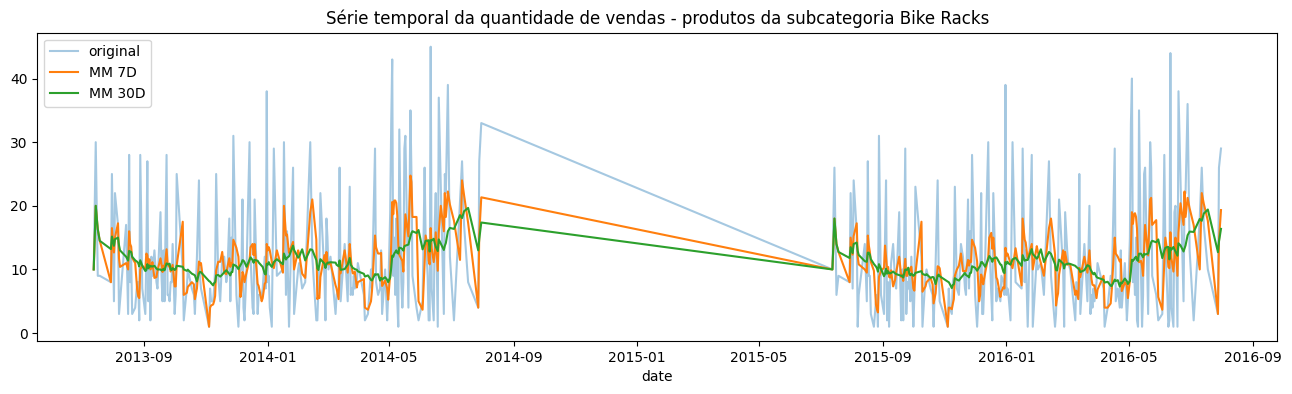

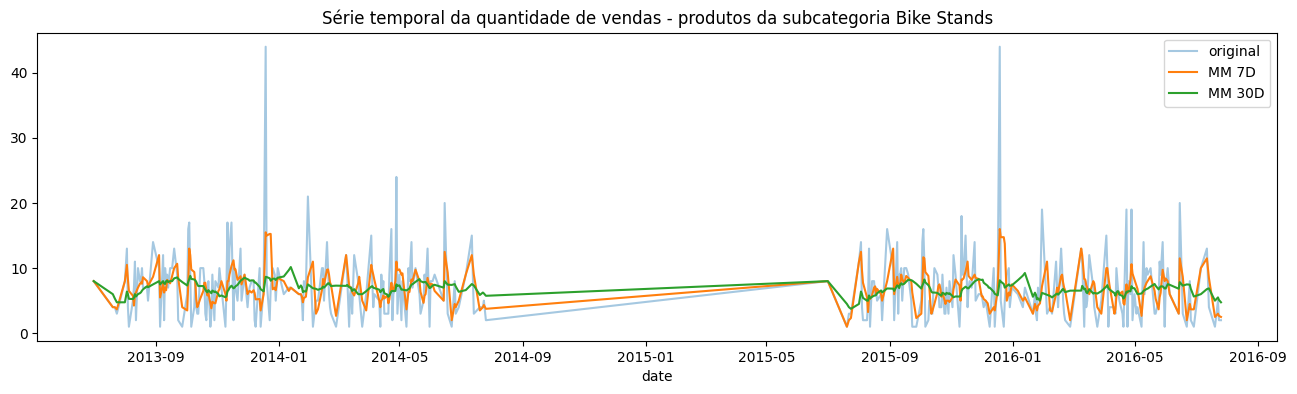

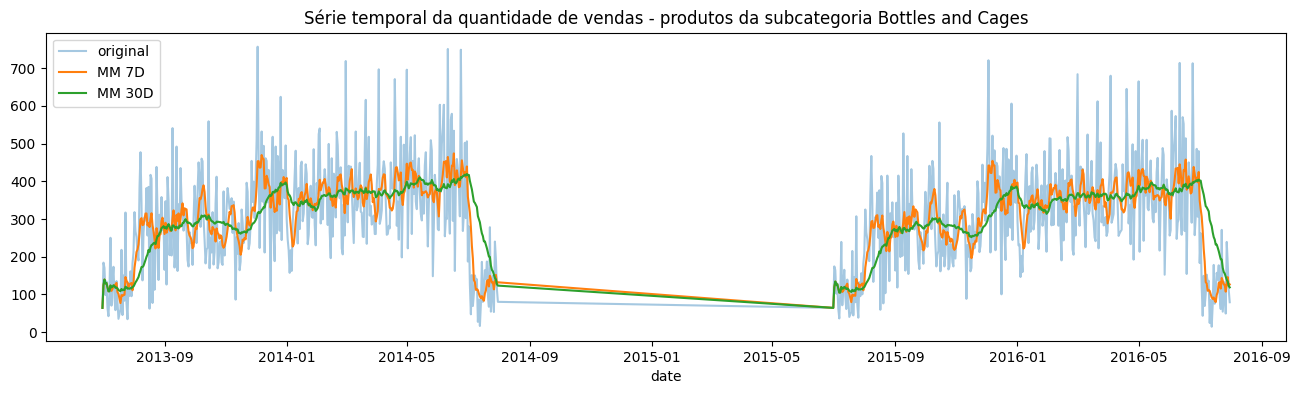

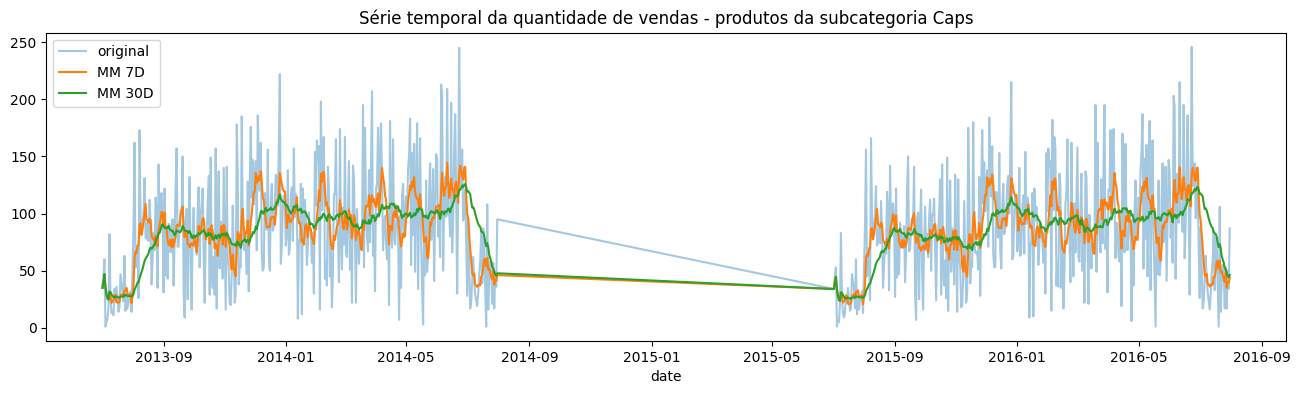

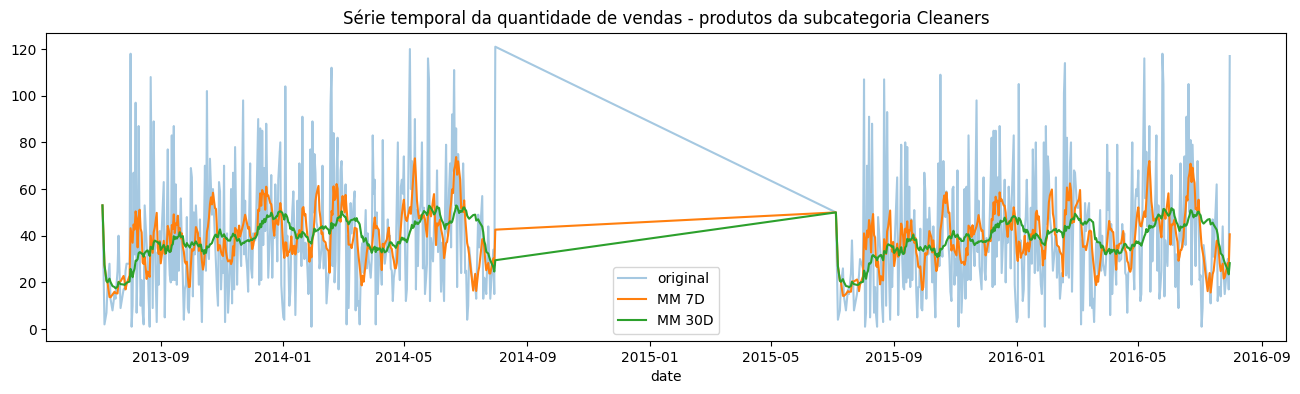

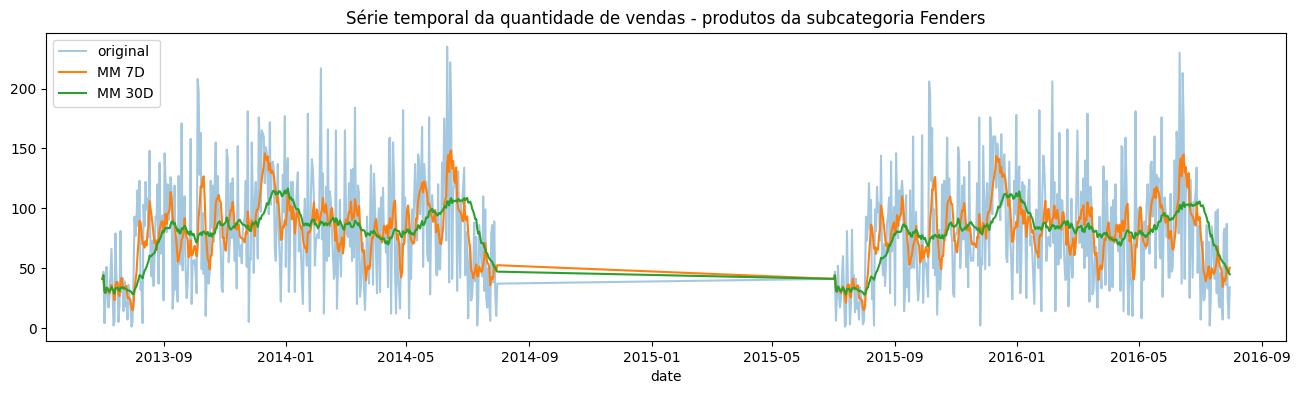

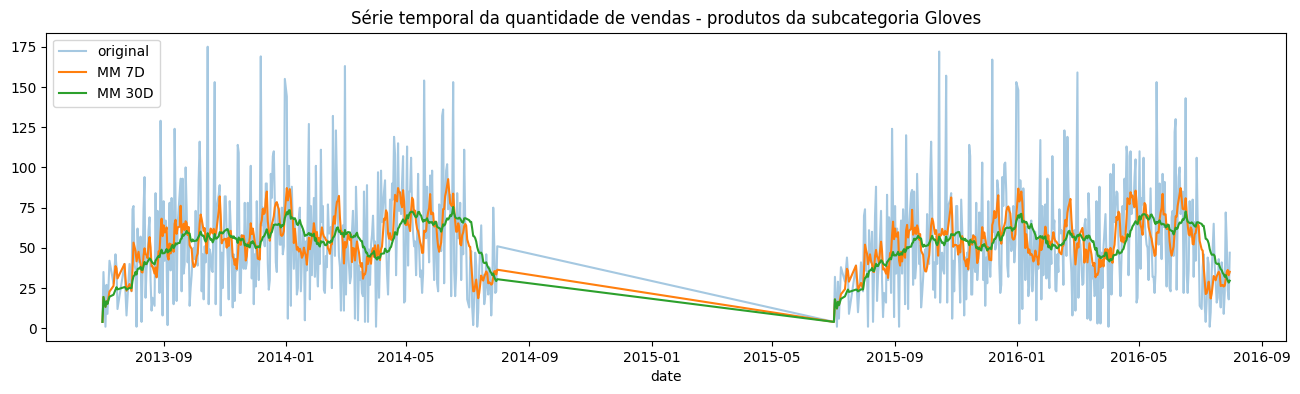

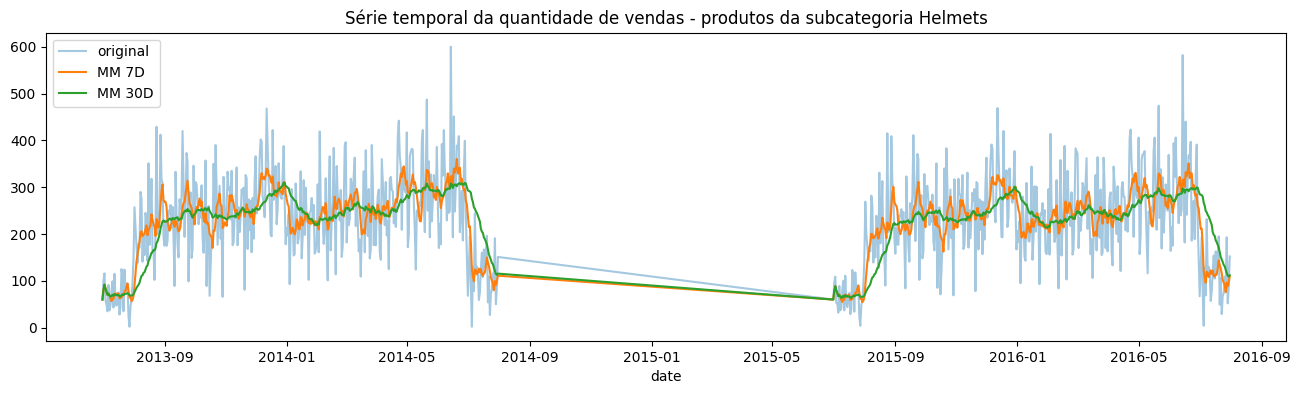

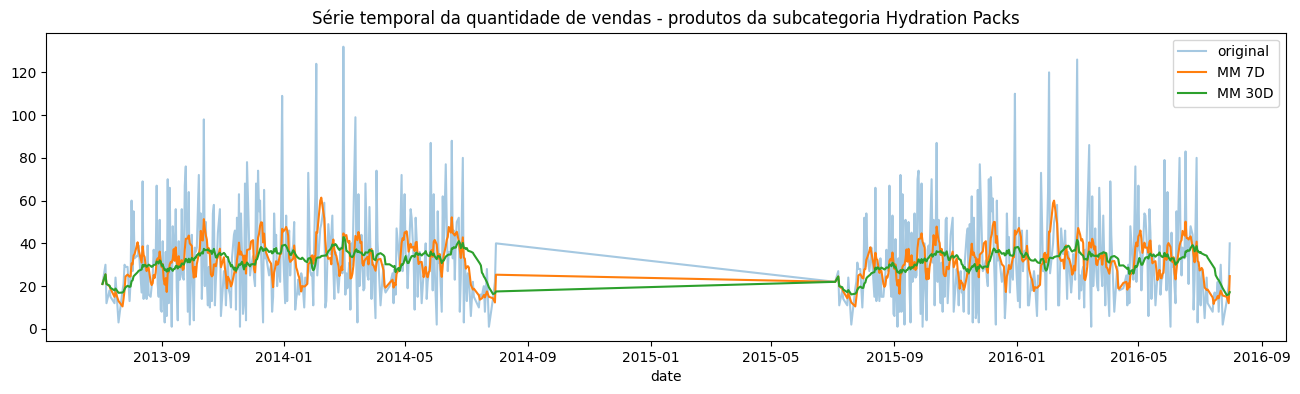

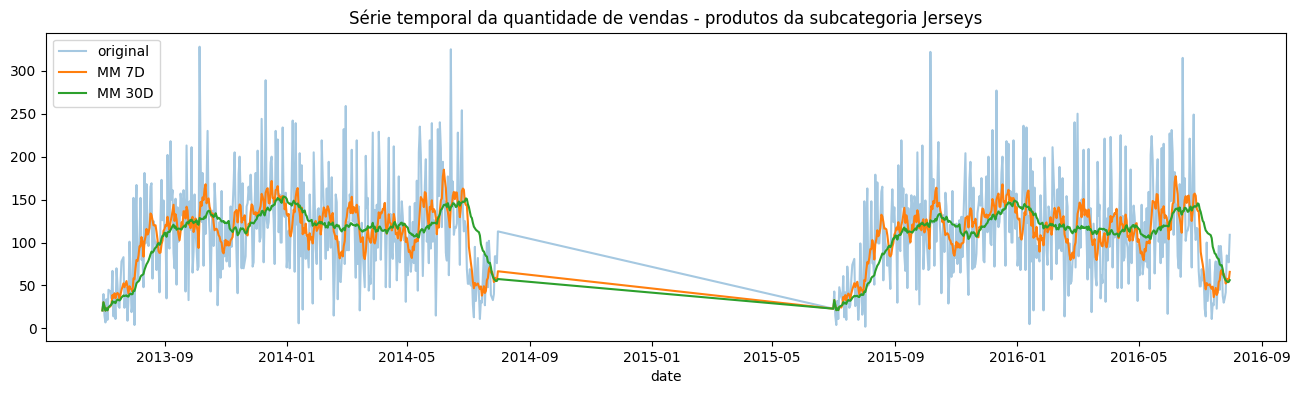

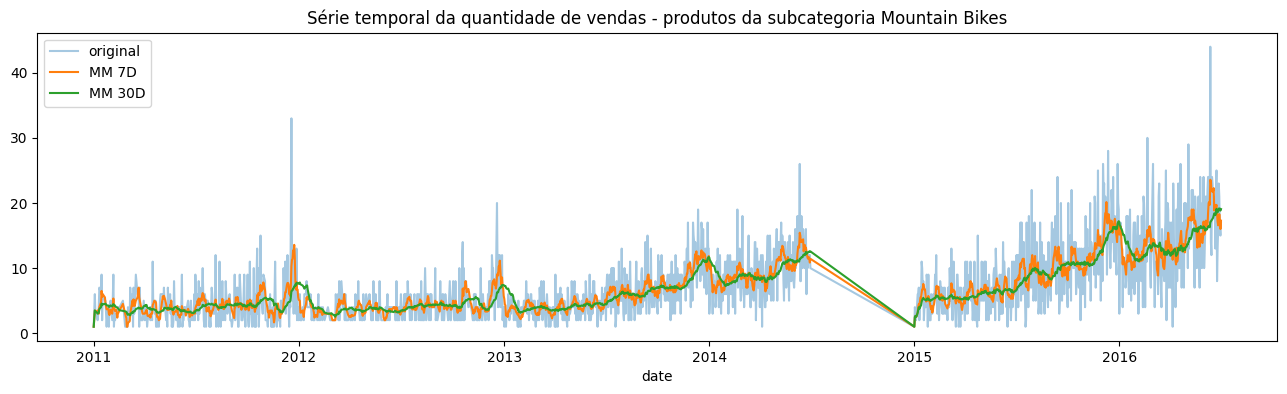

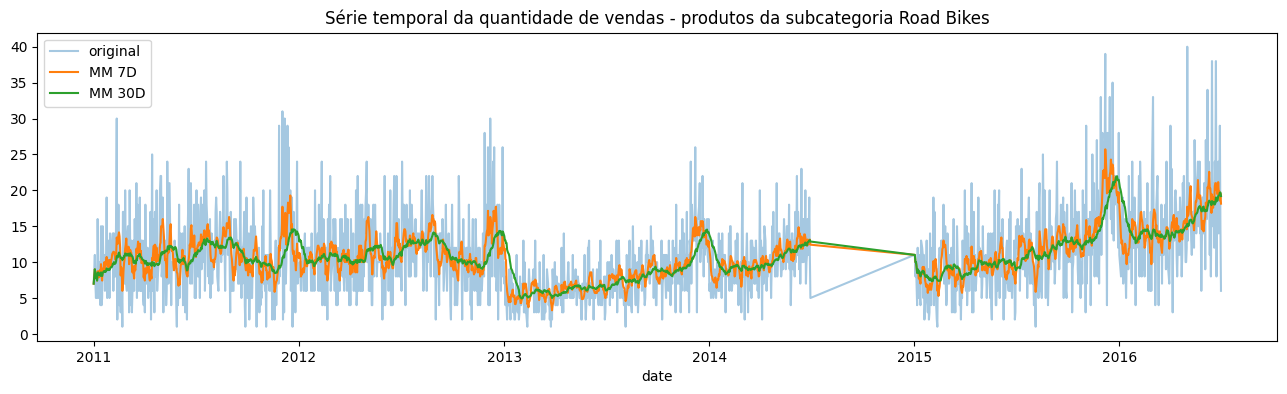

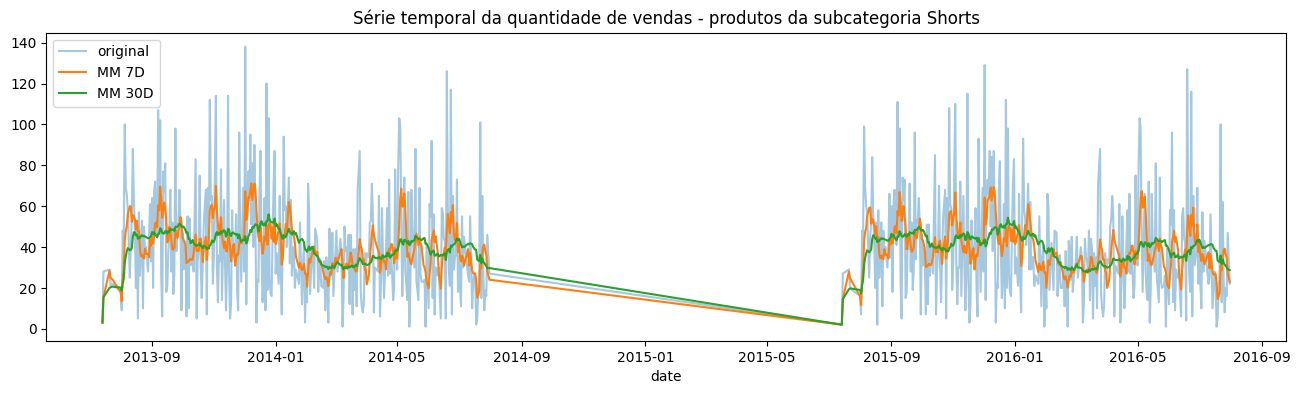

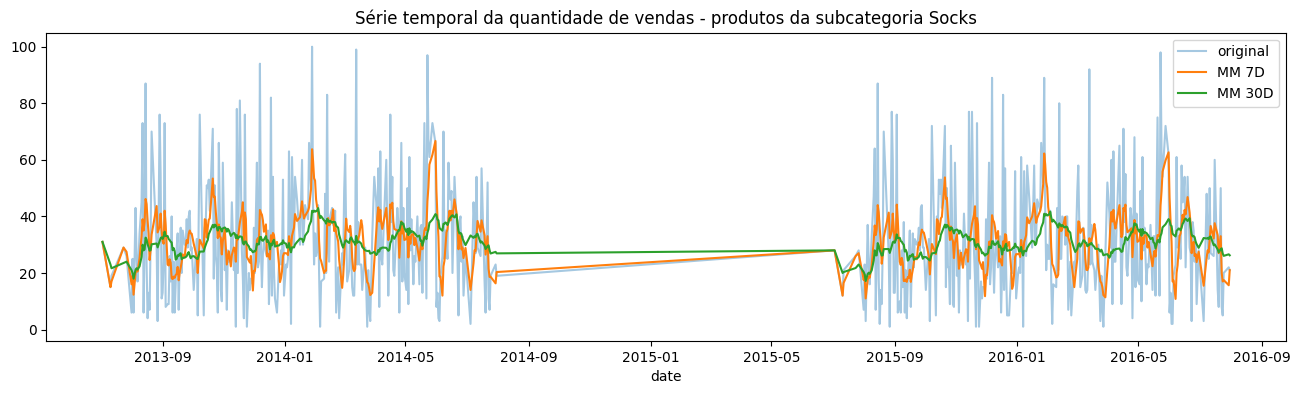

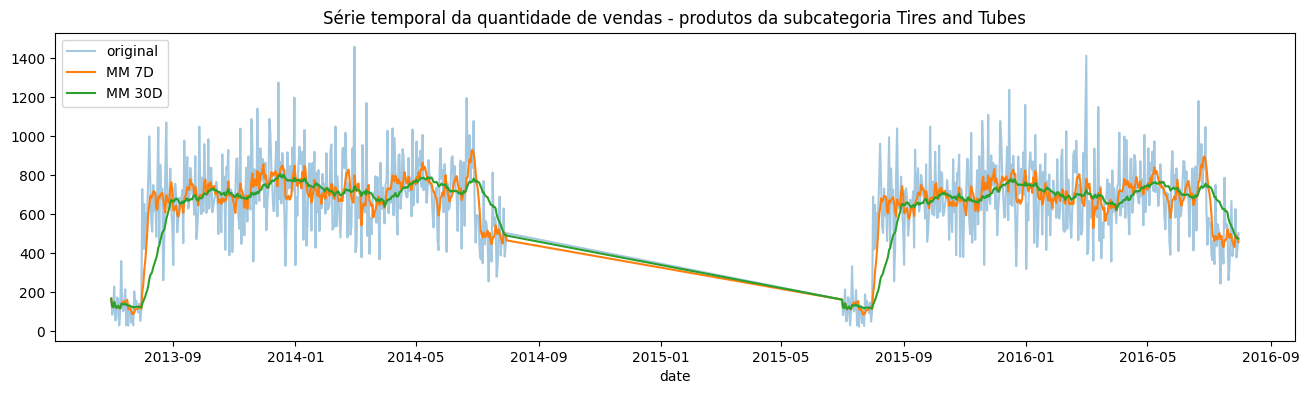

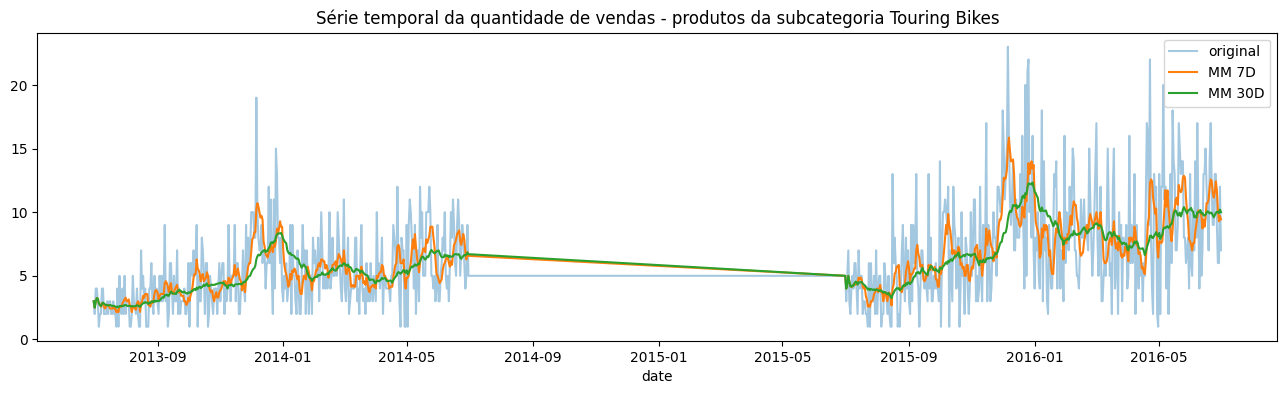

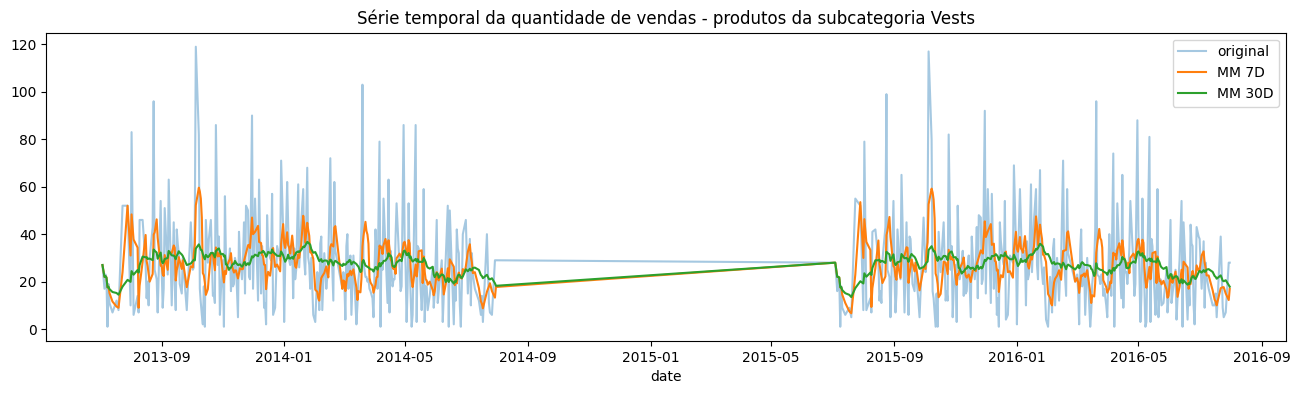

In [98]:
for subcat in df["sub_category"].sort_values().unique():

    df_category = df.query(f"sub_category == '{subcat}'")

    qtdd_total = df_category.groupby("date")[["order_quantity"]].sum()

    qtdd_total_7d = qtdd_total.rolling(window="7D").mean()
    qtdd_total_30d = qtdd_total.rolling(window="30D").mean()

    plt.figure(figsize=(16, 4))
    plt.title(f"Série temporal da quantidade de vendas - produtos da subcategoria {subcat}")

    sns.lineplot(x=qtdd_total.index, y=qtdd_total.values.squeeze(), label="original", alpha=0.4)
    sns.lineplot(x=qtdd_total_7d.index, y=qtdd_total_7d.values.squeeze(), label="MM 7D")
    sns.lineplot(x=qtdd_total_30d.index, y=qtdd_total_30d.values.squeeze(), label="MM 30D")

    plt.show()

 **4. Existe alguma sazonalidade nas vendas ao longo do tempo?**
 * Sim, a análise mostra que as vendas apresentam padrões sazonais. Observamos um aumento nas vendas a partir de 2013, um pico em 2014, seguido de uma queda e uma nova recuperação em 2015. Isso indica possíveis fatores sazonais ou variações no mercado que afetam a demanda ao longo do tempo.


5. **Análise de Margem de Lucro**
   - Quais produtos ou categorias têm a maior margem de lucro?
   - Como otimizar o mix de produtos para maximizar a lucratividade?

In [99]:
df["margem"] = df["profit"]/df["revenue"]

In [100]:
df["margem"].describe()

count    113036.000000
mean          0.472518
std           0.163577
min          -0.037037
25%           0.357143
50%           0.526316
75%           0.596774
max           0.750000
Name: margem, dtype: float64

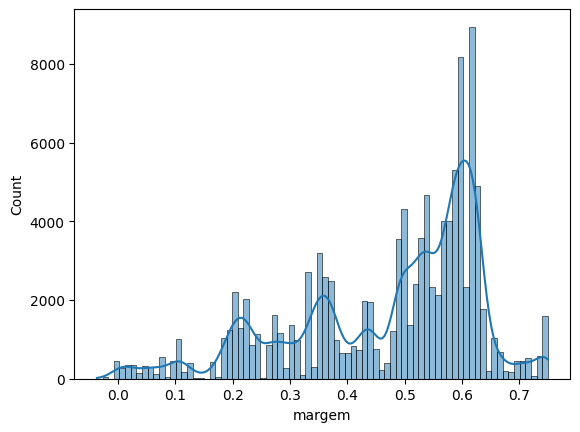

In [101]:
sns.histplot(data=df, x="margem", kde=True);

In [102]:
df["profit"].sum(), df["revenue"].sum()

(32221100, 85271008)

In [103]:
# margem de lucrto "global", em todo o período

df["profit"].sum()/df["revenue"].sum()

0.37786700023529685

In [104]:
anos = []
margens = []

for ano in df["year"].sort_values().unique():

    df_ano = df.query(f"year == {ano}")
    
    margem_ano = df_ano["profit"].sum()/df_ano["revenue"].sum()
    
    print(f"A margem de lucro de {ano} é: {margem_ano:.2%}")
    
    anos.append(ano)
    margens.append(margem_ano)

A margem de lucro de 2011 é: 32.14%
A margem de lucro de 2012 é: 32.17%
A margem de lucro de 2013 é: 39.10%
A margem de lucro de 2014 é: 41.43%
A margem de lucro de 2015 é: 37.60%
A margem de lucro de 2016 é: 39.72%


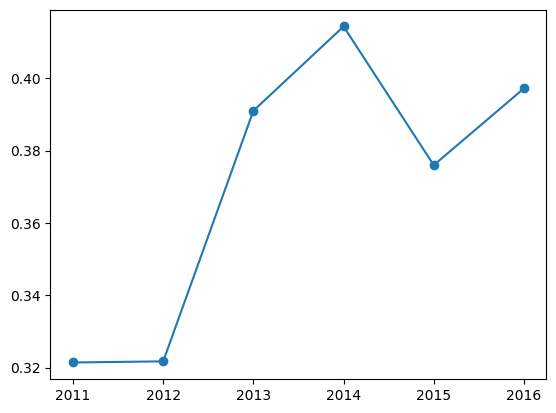

In [105]:
plt.plot(anos, margens, marker="o");

A margem de lucro para a categoria Accessories é: 58.62%


A margem de lucro para a categoria Bikes é: 33.21%


A margem de lucro para a categoria Clothing é: 33.92%


Distribuição das margens:


count    3.000000
mean     0.419181
std      0.144698
min      0.332123
25%      0.335664
50%      0.339205
75%      0.462710
max      0.586214
dtype: float64

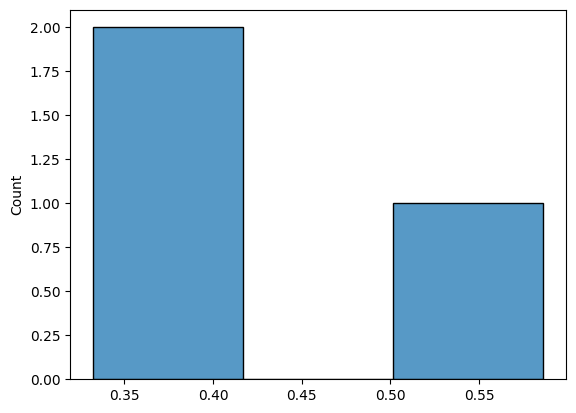

In [106]:
list_margens = []

for subcat in df["product_category"].sort_values().unique():

    df_category = df.query(f"product_category == '{subcat}'")
    
    margem_category = df_category["profit"].sum()/df_category["revenue"].sum()
    
    print(f"A margem de lucro para a categoria {subcat} é: {margem_category:.2%}")
    print(f"\n{'='*80}\n")
    
    list_margens.append(margem_category)
    
print("Distribuição das margens:")
display(pd.Series(list_margens).describe())

sns.histplot(list_margens);

A margem de lucro para a subcategoria Bike Racks é: 58.80%


A margem de lucro para a subcategoria Bike Stands é: 58.69%


A margem de lucro para a subcategoria Bottles and Cages é: 57.52%


A margem de lucro para a subcategoria Caps é: 14.20%


A margem de lucro para a subcategoria Cleaners é: 58.29%


A margem de lucro para a subcategoria Fenders é: 60.12%


A margem de lucro para a subcategoria Gloves é: 58.72%


A margem de lucro para a subcategoria Helmets é: 58.88%


A margem de lucro para a subcategoria Hydration Packs é: 57.82%


A margem de lucro para a subcategoria Jerseys é: 14.67%


A margem de lucro para a subcategoria Mountain Bikes é: 38.63%


A margem de lucro para a subcategoria Road Bikes é: 30.21%


A margem de lucro para a subcategoria Shorts é: 59.42%


A margem de lucro para a subcategoria Socks é: 63.31%


A margem de lucro para a subcategoria Tires and Tubes é: 58.40%


A margem de lucro para a subcategoria Touring Bikes é: 31.25%


A margem de lucro para a subc

count    17.000000
mean      0.490344
std       0.164715
min       0.141990
25%       0.386321
50%       0.582891
75%       0.587978
max       0.633080
dtype: float64

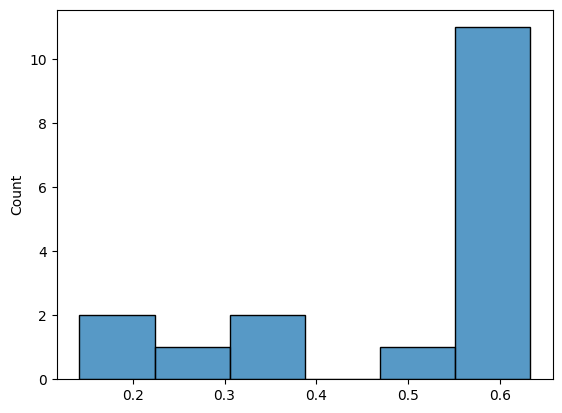

In [107]:
list_margens = []

for subcat in df["sub_category"].sort_values().unique():

    df_subcategory = df.query(f"sub_category == '{subcat}'")
    
    margem_subcategory = df_subcategory["profit"].sum()/df_subcategory["revenue"].sum()
    
    print(f"A margem de lucro para a subcategoria {subcat} é: {margem_subcategory:.2%}")
    print(f"\n{'='*80}\n")
    
    list_margens.append(margem_subcategory)
    
print("Distribuição das margens:")
display(pd.Series(list_margens).describe())

sns.histplot(list_margens);

A margem de lucro para a categoria AWC Logo Cap é: 14.20%


A margem de lucro para a categoria All-Purpose Bike Stand é: 58.68%


A margem de lucro para a categoria Bike Wash - Dissolver é: 58.37%


A margem de lucro para a categoria Classic Vest, L é: 58.50%


A margem de lucro para a categoria Classic Vest, M é: 58.02%


A margem de lucro para a categoria Classic Vest, S é: 58.98%


A margem de lucro para a categoria Fender Set - Mountain é: 60.12%


A margem de lucro para a categoria HL Mountain Tire é: 59.74%


A margem de lucro para a categoria HL Road Tire é: 58.87%


A margem de lucro para a categoria Half-Finger Gloves, L é: 58.48%


A margem de lucro para a categoria Half-Finger Gloves, M é: 58.61%


A margem de lucro para a categoria Half-Finger Gloves, S é: 59.02%


A margem de lucro para a categoria Hitch Rack - 4-Bike é: 58.81%


A margem de lucro para a categoria Hydration Pack - 70 oz. é: 57.82%


A margem de lucro para a categoria LL Mountain Tire é: 59.71%


A margem d

count    130.000000
mean       0.379454
std        0.137084
min        0.102301
25%        0.294074
50%        0.324585
75%        0.439841
max        0.724936
dtype: float64

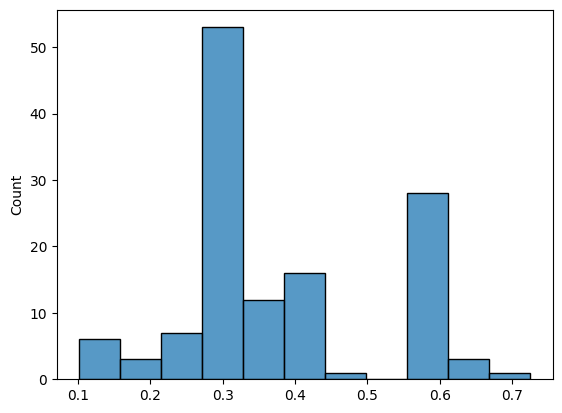

In [108]:
list_margens = []

for produto in df["product"].sort_values().unique():

    df_produto = df.query(f'product == "{produto}"')
    
    margem_produto = df_produto["profit"].sum()/df_produto["revenue"].sum()
    
    print(f"A margem de lucro para a categoria {produto} é: {margem_produto:.2%}")
    print(f"\n{'='*80}\n")
    
    list_margens.append(margem_produto)
    
print("Distribuição das margens:")
display(pd.Series(list_margens).describe())

sns.histplot(list_margens);

In [109]:
top10 = (
    df
    .groupby("product_category product".split())[["order_quantity"]]
    .sum()
    .reset_index()
    .sort_values("order_quantity", ascending=False)
    .head(10)
)["product"]

In [110]:
top10

22       Water Bottle - 30 oz.
14         Patch Kit/8 Patches
13          Mountain Tire Tube
111               AWC Logo Cap
19       Sport-100 Helmet, Red
16              Road Tire Tube
17     Sport-100 Helmet, Black
3        Fender Set - Mountain
21           Touring Tire Tube
18      Sport-100 Helmet, Blue
Name: product, dtype: object

In [111]:
for produto in top10:

    df_produto = df.query(f'product == "{produto}"')
    
    margem_produto = df_produto["profit"].sum()/df_produto["revenue"].sum()
    
    print(f"A margem de lucro para a categoria {produto} é: {margem_produto:.2%}")
    print(f"\n{'='*80}\n")

A margem de lucro para a categoria Water Bottle - 30 oz. é: 56.01%


A margem de lucro para a categoria Patch Kit/8 Patches é: 44.49%


A margem de lucro para a categoria Mountain Tire Tube é: 56.25%


A margem de lucro para a categoria AWC Logo Cap é: 14.20%


A margem de lucro para a categoria Sport-100 Helmet, Red é: 59.01%


A margem de lucro para a categoria Road Tire Tube é: 72.49%


A margem de lucro para a categoria Sport-100 Helmet, Black é: 58.57%


A margem de lucro para a categoria Fender Set - Mountain é: 60.12%


A margem de lucro para a categoria Touring Tire Tube é: 55.89%


A margem de lucro para a categoria Sport-100 Helmet, Blue é: 59.06%





 **5. Qual faixa etária mais consome os produtos?**
*  A análise da distribuição de clientes por faixa etária mostra que a maioria dos consumidores está no grupo adulto (35-64 anos). Esse dado é relevante para estratégias de marketing e definição de público-alvo.


6. **Eficiência de Custos**
   - Qual é a relação entre o custo unitário e o preço unitário dos produtos?
   - Existem oportunidades para reduzir custos e aumentar a margem de lucro?

In [112]:
df["custo_receita"] = df["unit_cost"]/df["unit_price"]

df["custo_receita"].describe()

count    113036.000000
mean          0.472464
std           0.138120
min           0.250000
25%           0.371429
50%           0.400000
75%           0.546296
max           0.777778
Name: custo_receita, dtype: float64

A razão custo/preço do produto AWC Logo Cap é: 77.78%


A razão custo/preço do produto All-Purpose Bike Stand é: 37.11%


A razão custo/preço do produto Bike Wash - Dissolver é: 37.50%


A razão custo/preço do produto Classic Vest, L é: 37.50%


A razão custo/preço do produto Classic Vest, M é: 37.50%


A razão custo/preço do produto Classic Vest, S é: 37.50%


A razão custo/preço do produto Fender Set - Mountain é: 36.36%


A razão custo/preço do produto HL Mountain Tire é: 37.14%


A razão custo/preço do produto HL Road Tire é: 36.36%


A razão custo/preço do produto Half-Finger Gloves, L é: 37.50%


A razão custo/preço do produto Half-Finger Gloves, M é: 37.50%


A razão custo/preço do produto Half-Finger Gloves, S é: 37.50%


A razão custo/preço do produto Hitch Rack - 4-Bike é: 37.50%


A razão custo/preço do produto Hydration Pack - 70 oz. é: 38.18%


A razão custo/preço do produto LL Mountain Tire é: 36.00%


A razão custo/preço do produto LL Road Tire é: 38.10%


A razão custo/

count    130.000000
mean       0.554733
std        0.120097
min        0.250000
25%        0.511283
50%        0.606764
75%        0.621967
max        0.777778
dtype: float64

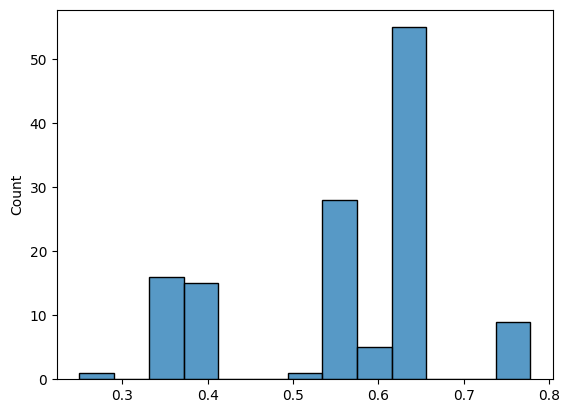

In [113]:
list_cr = []

for produto in df["product"].sort_values().unique():

    df_produto = df.query(f'product == "{produto}"')
    
    cr = df_produto["unit_cost"]/df_produto["unit_price"]
    
    for cr_unique in cr.unique():
        print(f"A razão custo/preço do produto {produto} é: {cr_unique:.2%}")
        
        list_cr.append(cr_unique)
    
    print(f"\n{'='*80}\n")
    
print("Distribuição das margens:")
display(pd.Series(list_cr).describe())

sns.histplot(list_cr);

In [114]:
for produto in top10:

    df_produto = df.query(f'product == "{produto}"')
    
    cr = df_produto["unit_cost"]/df_produto["unit_price"]
    
    for cr_unique in cr.unique():
        print(f"A razão custo/preço do produto {produto} é: {cr_unique:.2%}")
    
    print(f"\n{'='*80}\n")

A razão custo/preço do produto Water Bottle - 30 oz. é: 40.00%


A razão custo/preço do produto Patch Kit/8 Patches é: 50.00%


A razão custo/preço do produto Mountain Tire Tube é: 40.00%


A razão custo/preço do produto AWC Logo Cap é: 77.78%


A razão custo/preço do produto Sport-100 Helmet, Red é: 37.14%


A razão custo/preço do produto Road Tire Tube é: 25.00%


A razão custo/preço do produto Sport-100 Helmet, Black é: 37.14%


A razão custo/preço do produto Fender Set - Mountain é: 36.36%


A razão custo/preço do produto Touring Tire Tube é: 40.00%


A razão custo/preço do produto Sport-100 Helmet, Blue é: 37.14%





 **6. Quais são os produtos mais vendidos?**
* Os produtos mais vendidos foram identificados por meio da soma da quantidade de pedidos. A análise revelou os 10 produtos mais vendidos, que podem ser utilizados para otimização de estoque, promoções e campanhas de vendas.

7. **Comportamento de Compra dos Clientes**
   - Qual é a frequência de compra dos clientes?
   - Existem clientes recorrentes e qual é o seu impacto nas vendas totais?

In [115]:
df.columns

Index(['date', 'day', 'month', 'year', 'customer_age', 'age_group',
       'customer_gender', 'country', 'state', 'product_category',
       'sub_category', 'product', 'order_quantity', 'unit_cost', 'unit_price',
       'profit', 'cost', 'revenue', 'month_num', 'margem', 'custo_receita'],
      dtype='object')

## Há mais o que explorar! Por exemplo, analisar lucro ao invés de quantidade de compras:

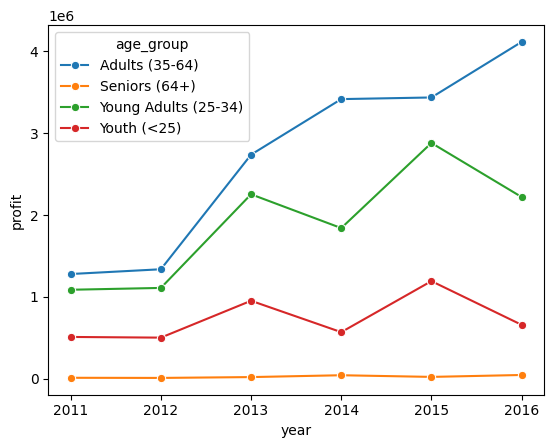

In [116]:
faixa_etaria_ano_profit = df.groupby("age_group year".split())[["profit"]].sum().reset_index()

sns.lineplot(data=faixa_etaria_ano_profit, x="year", y="profit", hue="age_group", marker="o");


 **7. Qual a margem de lucro por categoria de produto?**
* A margem de lucro foi calculada e agrupada por categoria de produto. Algumas categorias apresentam margens significativamente mais altas do que outras, o que pode orientar estratégias para aumentar a rentabilidade, como ajustes de preços ou priorização de vendas desses produtos.

## Conclusão da Análise de Vendas de Bicicletas  

A partir da análise dos dados de vendas, identificamos padrões importantes que podem ser utilizados para tomada de decisão estratégica.  

### Principais Insights  

1. **Tendência de Vendas ao Longo do Tempo:**  
   As vendas apresentaram um crescimento expressivo a partir de 2013, atingindo um pico em 2014, seguido por uma queda e uma recuperação gradual em 2015. Essa variação pode estar associada a fatores sazonais ou mudanças no mercado, sendo essencial um monitoramento contínuo para antecipar tendências futuras.  

2. **Perfil do Consumidor:**  
   A maioria dos clientes pertence à faixa etária de 35 a 64 anos, indicando que esse grupo representa o público-alvo predominante. Estratégias de marketing e campanhas promocionais podem ser otimizadas para atender melhor às preferências e necessidades desse segmento.  

3. **Produtos Mais Vendidos:**  
   A análise revelou os 10 produtos mais vendidos, proporcionando insights valiosos para a gestão de estoque e planejamento de promoções. Conhecer os produtos de maior demanda permite uma alocação mais eficiente de recursos e estratégias voltadas à fidelização de clientes.  

4. **Margem de Lucro por Categoria de Produto:**  
   Algumas categorias de produtos apresentaram margens de lucro consideravelmente mais altas do que outras. Esse dado é crucial para o desenvolvimento de estratégias de precificação, mix de produtos e investimentos focados na rentabilidade.  

### Direcionamento Estratégico  

Com base nos insights obtidos, algumas ações podem ser sugeridas:  

- Implementar um planejamento de estoque alinhado às variações sazonais identificadas.  
- Direcionar campanhas de marketing e ofertas para o público adulto (35-64 anos), que constitui a maior base de clientes.  
- Priorizar produtos de alta demanda e avaliar oportunidades para expandir seu portfólio com itens similares.  
- Explorar estratégias de precificação e promoções para aumentar a venda de produtos com maior margem de lucro.  

A análise demonstrou que o conhecimento baseado em dados é essencial para maximizar resultados e tomar decisões mais assertivas. Monitorar continuamente essas métricas permitirá otimizar ainda mais as estratégias da empresa e garantir um crescimento sustentável.  
